[2006-03-13 Fiddler](https://thefiddler.substack.com/p/can-you-or-cantor-you-find-the-distance)
====================

Fiddler
-------
Let $d$ be the average distance.

The probability that the two points are on the same half is 50%, in which case the
average distance is $\frac d3$.

The probability that the two points are on different halves is 50%, so the probability
that the average distance is $\frac23 + \frac d3$ is 25%, and probability that the average
distance is $\frac23 - \frac d3$ is 25%.

So $d = \frac12\cdot\frac d3 + \frac14\cdot\left(\frac23 + \frac d3 + \frac23 - \frac d3\right) = \frac25$.

Extra credit
------------
Let $p$ be the probability.

The probability that all three distances are less than 1/3 is 1/8, in which case the
probability is $p$.

The probability that two of the distances are less than 1/3 is 3/8, in which case the
probability is $0$, since the third distance is more than 2/3.

The probability that one of the distances is less than 1/3 is 3/8, in which case the
probability is not immediately obvious, so call it $q$.

The probability that none of the distances are less than 1/3 is 1/8, in which case the
probability is $1$.

Then, $p = p/8 + 3q/8 + 1/8 = 3q/7 + 1/7$.

Based on numerical simulations, I expect $p = 2/5$, so I expect $q = 3/5$.

### Calculating $q$
$q$ is the probability that the small value is greater than the difference between the
two large values.

Let $q = Q(0,2/3,2/3,1/3)$, where $Q(a,b,c,f)$ is the probability that the first value,
which is between $a$ and $a+f$, is greater than the difference between the second value,
which is between $b$ and $b+f$, and the third value, which is between $c$ and $c+f$.

A few properties are $Q(a,b,c,f) = Q(a,c,b,f)$, $Q(a,b+x,c+x,f) = Q(a,b,c,f)$.  And, assuming
$c \ge b$, $Q(a+x,b,c+x,f) = Q(a,b,c,f)$.

From this point on, I'll assume $c \ge b$, using $Q(a,b,c,f) = Q(a,c,b,f)$.

If $a \ge c - b + f$, then $Q = 1$.

If $a \le c - b - f$, then $Q = 0$.

Otherwise,

$$\begin{aligned} Q(a,b,c,f) = \frac18(
    & Q(a,b,c,f/3) &+ Q(a+2f/3,b,c,f/3) &+ Q(a,b+2f/3,c,f/3) &+ Q(a+2f/3,b+2f/3,c,f/3) \\
    + & Q(a,b,c+2f/3,f/3) &+ Q(a+2f/3,b,c+2f/3,f/3) &+ Q(a,b+2f/3,c+2f/3,f/3) &+ Q(a+2f/3,b+2f/3,c+2f/3,f/3)) \\
\end{aligned}$$

Numerical evaluations of partial sums of the probabilities point to the partial sums
converging to $3/5$, and thus pointing to the probability of the three random values
being the side lengths of a triangle being $2/5$.

I hope to revisit this and prove that $q = 3/5$.

In [1]:
def q(a,b,c,f,max_depth):
    if f < 1/3^max_depth:
        return 0
    if a >= abs(c-b)+f:
        return 1
    if a <= abs(c-b)-f:
        return 0
    d = 2*f/3
    return (q(a,b,c,f/3,max_depth)+q(a+d,b,c,f/3,max_depth)+q(a,b+d,c,f/3,max_depth)+q(a+d,b+d,c,f/3,max_depth)
            +q(a,b,c+d,f/3,max_depth)+q(a+d,b,c+d,f/3,max_depth)+q(a,b+d,c+d,f/3,max_depth)+q(a+d,b+d,c+d,f/3,max_depth))/8

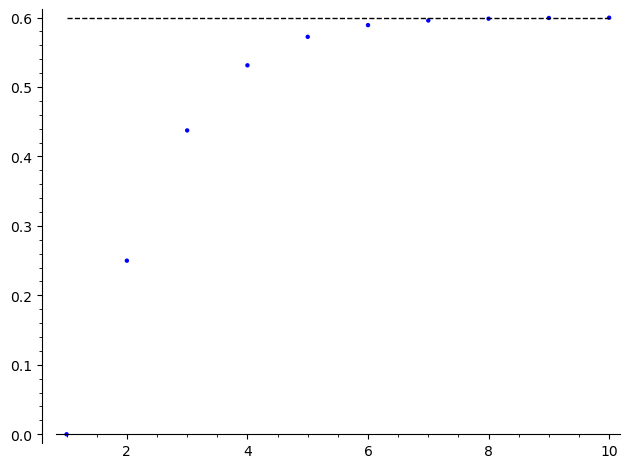

In [2]:
points([(n,q(0,2/3,2/3,1/3,n)) for n in [1..10]]) + line([(1,3/5),(10,3/5)],color="black",linestyle="dashed")

In [3]:
qs = [q(0,2/3,2/3,1/3,n) for n in [1..10]]
print(qs)
[numerical_approx(3/5-q) for q in qs]

[0, 1/4, 7/16, 17/32, 293/512, 2413/4096, 19523/32768, 156865/262144, 1257011/2097152, 10062457/16777216]


[0.600000000000000,
 0.350000000000000,
 0.162500000000000,
 0.0687500000000000,
 0.0277343750000000,
 0.0108886718750000,
 0.00420532226562500,
 0.00160751342773437,
 0.000610446929931641,
 0.000230824947357178]

Numerical simulations
---------------------
[Numerical simulations](20260313.go) agree.

    $ go run 20260313.go
    fiddler: 10000,5: 0.398648
    fiddler: 100000,5: 0.399611
    fiddler: 1000000,5: 0.399993
    fiddler: 10000000,5: 0.399951
    fiddler: 10000,10: 0.398759
    fiddler: 100000,10: 0.399663
    fiddler: 1000000,10: 0.399989
    fiddler: 10000000,10: 0.400031
    fiddler: 10000,15: 0.399379
    fiddler: 100000,15: 0.400152
    fiddler: 1000000,15: 0.400160
    fiddler: 10000000,15: 0.399994
    extra credit: 10000,5: 0.392725
    extra credit: 100000,5: 0.395184
    extra credit: 1000000,5: 0.394938
    extra credit: 10000000,5: 0.394911
    extra credit: 10000,10: 0.399163
    extra credit: 100000,10: 0.399904
    extra credit: 1000000,10: 0.399763
    extra credit: 10000000,10: 0.400018
    extra credit: 10000,15: 0.398300
    extra credit: 100000,15: 0.400449
    extra credit: 1000000,15: 0.400107
    extra credit: 10000000,15: 0.399942